## 인공지능 7주차

#### tanh의 기울기 확인하기

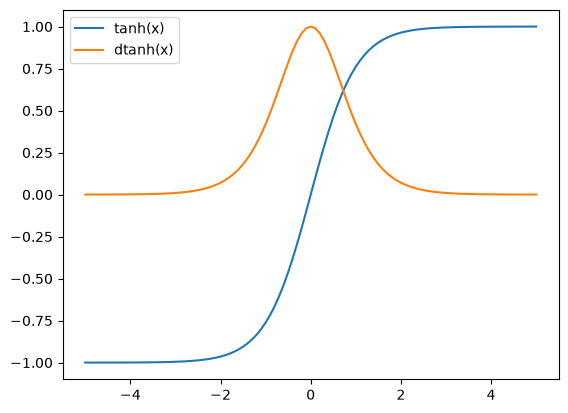

In [27]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5,5,101)
y = np.tanh(x)

fig, ax = plt.subplots()
ax.plot(x, y, label='tanh(x)')
ax.plot(x,  1- y**2, label = 'dtanh(x)')

ax.legend()
plt.show()


### 기울기 클리핑

In [28]:
dw1 = np.random.rand(3,3) * 10
dw2 = np.random.rand(3,3) * 10
grads = [dw1, dw2]
max_norm = 5.0

def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)
    
    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate

--- 
#### LSTM 구현하기

In [29]:
# LSTM
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None
        
    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        N, H = h_prev.shape # N: 미니배치 수, H: 은닉상태 원소 수
        
        A = np.matmul(x, Wx) + np.matmul(h_prev, Wh) + b
        
        #slice 
        f = A[:, :H]
        g = A[:, H:2*H]
        i = A[:, 2*H: 3*H]
        o = A[:, 3*H:4*H]
        
        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)
        
        c_next = (f * c_prev) + (g * i)
        h_next = o * np.tanh(c_next)
        
        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next
    
    def backward(self, dh_next, dc_next):
        Wx, Wh, b = self.params
        x, h_prev, c_prev, i, f, g, o, c_next = self.cache
        
        tanh_c_next = np.tanh(c_next)
        
        ds = dc_next + (dh_next * o) * (1 - tanh_c_next ** 2)
        
        dc_prev = ds * f
        
        di = ds * g
        df = ds * c_prev
        do = dh_next * tanh_c_next
        dg = ds * i
        
        di *= i * (1 - i)
        df *= f * (1 - f)
        
        do *= o * (1 - o)
        dg *= (1 - g ** 2)
        
        dA = np.hstack((df, dg, di, do))
        
        dWh = np.dot(h_prev.T, dA)
        dWx = np.dot(x.T, dA)
        db = dA.sum(axis=0)
        
        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db
        
        dx = np.dot(dA, Wx.T)
        dh_prev = np.dot(dA, Wh.T)
        
        return dx, dh_prev, dc_prev
        
        

--- 
#### 자연어 처리를 위한 TIME LSTM 구현하기

In [30]:
# Time LSTM
import numpy as np

class TimeLSTM:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None
        self.h, self.c = None, None
        self.dh = None
        self.stateful = stateful
        
    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        H = Wh.shape[0]
        
        self.layers = []
        hs=np.empty((N,T,H), dtype = 'f')
        
        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype = 'f')
        if not self.stateful or self.c is None:
            self.c = np.zeros((N,H), dtype = 'f')
            
        for t in range(T):
            layer = LSTM(*self.params)
            self.h, self.c = layer.forward(xs[:,t,:], self.h, self.c)
            hs[:,t,:] = self.h
            
            self.layers.append(layer)
            
        return hs
    
    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]
        
        dxs = np.empty((N, T, D), dtype = 'f')
        dh, dc = 0, 0
        
        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:,t,:] + dh, dc)
            dxs[:,t,:] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad
                
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        
        self.dh = dh
        return dxs
        
    def set_state(self, h, c=None):
        self.h,self.c = h, c
        
    def reset_state(self):
        self.h, self.c = None, None
        

In [31]:
# Time Embedding
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        return W[idx]

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        np.add.at(dW, self.idx, dout)  # 같은 단어가 여러 번 나온 경우 기울기를 합산
        return None


class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.W.shape
        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)
        return out

    def backward(self, dout):
        N, T, D = dout.shape
        grad = np.zeros_like(self.W)

        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

# Time Affine
class TimeAffine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        N, T, D = x.shape
        W, b = self.params
        rx = x.reshape(N * T, D)
        out = np.dot(rx, W) + b
        self.x = x
        return out.reshape(N, T, -1)

    def backward(self, dout):
        x = self.x
        N, T, D = x.shape
        W, b = self.params
        dout = dout.reshape(N * T, -1)
        rx = x.reshape(N * T, D)

        self.grads[0][...] = np.dot(rx.T, dout)
        self.grads[1][...] = np.sum(dout, axis=0)
        dx = np.dot(dout, W.T)
        return dx.reshape(N, T, D)
    
    
# Time Softmax With Loss
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / exp_x.sum(axis=1, keepdims=True)

    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()

class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        N, T, V = xs.shape
        if ts.ndim == 3:  # 정답이 원-핫 벡터일 때
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        log_likelihood = np.log(ys[np.arange(N * T), ts] + 1e-7)
        loss = -np.sum(log_likelihood * mask) / mask.sum()
        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache
        dx = ys.copy()
        dx[np.arange(N * T), ts] -= 1
        dx *= dout / mask.sum()
        dx *= mask[:, np.newaxis]
        return dx.reshape(N, T, V)


In [32]:
class LSTMlm:
    def __init__(self, vocab_size = 10000, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        # Wx, Wh, b: f, g, i, o 벡터를 계산하기에 (D, 4 * H) shape으로 설정
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # TimeEmbedding -> TimeLSTM -> TimeAffine
        self.layers = [
            TimeEmbedding(embed_W),
            TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]

        # 각 계층의 매개변수와 기울기를 하나의 리스트로 모은다.
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs):
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts):
        scores = self.predict(xs)
        return self.loss_layer.forward(scores, ts)

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.lstm_layer.reset_state()


### Lab1: Time 계층을 조합한 LSTM 언어 모델

`TimeEmbedding → TimeLSTM → TimeAffine → TimeSoftmaxWithLoss`

In [33]:
# Project Gutenberg에서 Alice 원문 내려받기
!curl -L -o alice.txt https://gutenberg.org/cache/epub/11/pg11.txt

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 170.2k 100 170.2k   0      0 108.0k      0   00:01   00:01              0
100 170.2k 100 170.2k   0      0 108.0k      0   00:01   00:01              0
100 170.2k 100 170.2k   0      0 108.0k      0   00:01   00:01              0


사용 단어 수: 5000
앞부분: ['[illustration]', 'alice’s', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3.0', 'contents', 'chapter', 'i.', 'down', 'the', 'rabbit-hole', 'chapter']
어휘 수: 1553
epoch  1 | loss 7.2469 | perplexity 1403.80
epoch  2 | loss 6.9062 | perplexity 998.40
epoch  3 | loss 6.5387 | perplexity 691.39
epoch  4 | loss 6.3941 | perplexity 598.32
epoch  5 | loss 6.3231 | perplexity 557.29


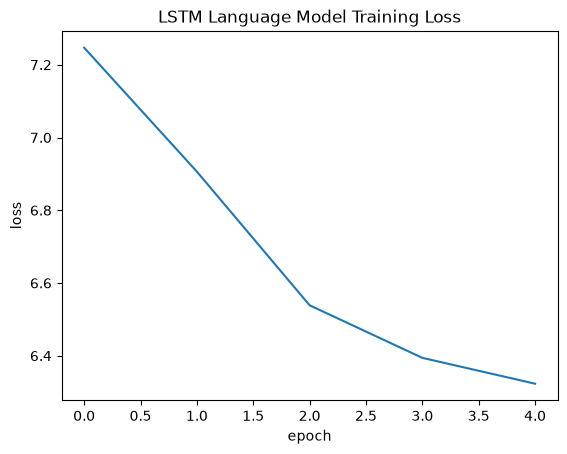

In [ ]:
# 1. 내려받은 Alice 원문 읽기
with open('alice.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

# 안내문 제외하고 소설 본문만 사용.
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"

if start_marker in text:
    text = text.split(start_marker, 1)[1]
if end_marker in text:
    text = text.split(end_marker, 1)[0]

tokens = text.lower().split()
tokens = tokens[:5000]  # 처음 5,000단어만 사용

print('사용 단어 수:', len(tokens))
print('앞부분:', tokens[:20])

# 2. 단어와 단어 ID 사전 만들기
word_to_id = {}
id_to_word = {}
for word in tokens:
    if word not in word_to_id:
        new_id = len(word_to_id)
        word_to_id[word] = new_id
        id_to_word[new_id] = word

print('어휘 수:', len(word_to_id))

# 3. 모든 단어를 숫자 ID로 바꾼다.
corpus = np.array([word_to_id[word] for word in tokens], dtype=np.int32)

# LAB2에서 같은 변수명을 사용하므로 Alice 데이터는 별도 이름으로 보관한다.
alice_corpus = corpus
alice_word_to_id = word_to_id
alice_id_to_word = id_to_word
xs, ts = corpus[:-1], corpus[1:]

# 4. TimeLSTM 언어 모델 학습
np.random.seed(42)
batch_size, time_size = 5, 5
model = LSTMlm(vocab_size=len(word_to_id), wordvec_size=16, hidden_size=32)
learning_rate, max_epoch = 0.1, 5
data_size = len(xs)
jump = data_size // batch_size
offsets = [i * jump for i in range(batch_size)]
max_iters = data_size // (batch_size * time_size) # 한 epoch에서 미니배치 학습을 몇 번 실행할지 나타냄
time_idx = 0
loss_history = []

for epoch in range(1, max_epoch + 1):
    epoch_loss = 0.0
    for _ in range(max_iters):
        batch_x = np.empty((batch_size, time_size), dtype=np.int32)
        batch_t = np.empty((batch_size, time_size), dtype=np.int32)
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        loss = model.forward(batch_x, batch_t)
        model.backward()
        clip_grads(model.grads, max_norm=5.0)
        for param, grad in zip(model.params, model.grads):
            param -= learning_rate * grad
        epoch_loss += loss

    mean_loss = epoch_loss / max_iters
    loss_history.append(mean_loss)
    
    print(f'epoch {epoch:2d} | loss {mean_loss:.4f} | perplexity {np.exp(mean_loss):.2f}')


plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('LSTM Language Model Training Loss')
plt.show()


--- 
## LAB2: 일반 RNN과 LSTM 언어 모델 성능 비교


WikiText-2 일부를 80% 학습 데이터와 20% 테스트 데이터로 나눈 뒤, 같은 조건에서 `SimpleRNNlm`과 `LSTMlm`의 perplexity와 학습 시간을 비교한다.

In [35]:
%pip install datasets -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

# 실습 시간을 줄이기 위해 train 데이터의 앞부분만 사용한다.
text = " ".join(dataset["train"]["text"][:200])

words = text.lower().split()[:5000]

print('전체 단어 수:', len(words))

전체 단어 수: 5000


In [ ]:
word_to_id = {}
id_to_word = {}

for word in words:
    if word not in word_to_id:
        word_id = len(word_to_id)
        word_to_id[word] = word_id
        id_to_word[word_id] = word

corpus = np.array([word_to_id[word] for word in words], dtype=np.int32)

# 앞의 80%는 학습, 뒤의 20%는 테스트에 사용한다.
split_index = int(len(corpus) * 0.8)
train_corpus = corpus[:split_index]
test_corpus = corpus[split_index:]

print('어휘 수:', len(word_to_id))
print('Train 크기:', len(train_corpus))
print('Test 크기:', len(test_corpus))

어휘 수: 1411
Train 크기: 4000
Test 크기: 1000


In [38]:
# 비교 대상으로 사용할 기본 RNN과 TimeRNN
class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        h_next = np.tanh(np.dot(x, Wx) + np.dot(h_prev, Wh) + b)
        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache
        dt = dh_next * (1 - h_next ** 2)

        self.grads[0][...] = np.dot(x.T, dt)
        self.grads[1][...] = np.dot(h_prev.T, dt)
        self.grads[2][...] = np.sum(dt, axis=0)

        dx = np.dot(dt, Wx.T)
        dh_prev = np.dot(dt, Wh.T)
        return dx, dh_prev


class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None
        self.h = None
        self.dh = None
        self.stateful = stateful

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        H = Wh.shape[0]
        hs = np.empty((N, T, H), dtype='f')
        self.layers = []

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype='f')

        for t in range(T):
            layer = RNN(*self.params)
            self.h = layer.forward(xs[:, t, :], self.h)
            hs[:, t, :] = self.h
            self.layers.append(layer)
        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]
        dxs = np.empty((N, T, D), dtype='f')
        dh = 0
        grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]

        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:, t, :] + dh)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh
        return dxs

    def reset_state(self):
        self.h = None


class SimpleRNNlm:
    def __init__(self, vocab_size, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        return self.loss_layer.forward(xs, ts)

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()



[Simple RNN]
epoch  1 | train PPL 1360.50
epoch  2 | train PPL 1244.14
epoch  3 | train PPL 1093.12
epoch  4 | train PPL 917.54
epoch  5 | train PPL 779.68
epoch  6 | train PPL 697.58
epoch  7 | train PPL 644.57
epoch  8 | train PPL 605.29
epoch  9 | train PPL 574.05
epoch 10 | train PPL 548.26
epoch 11 | train PPL 526.39
epoch 12 | train PPL 507.41
epoch 13 | train PPL 490.65
epoch 14 | train PPL 475.66
epoch 15 | train PPL 462.13
epoch 16 | train PPL 449.85
epoch 17 | train PPL 438.63
epoch 18 | train PPL 428.28
epoch 19 | train PPL 418.65
epoch 20 | train PPL 409.61

[LSTM]
epoch  1 | train PPL 1368.32
epoch  2 | train PPL 1285.19
epoch  3 | train PPL 1205.77
epoch  4 | train PPL 1126.08
epoch  5 | train PPL 1043.26
epoch  6 | train PPL 954.61
epoch  7 | train PPL 859.76
epoch  8 | train PPL 767.82
epoch  9 | train PPL 695.39
epoch 10 | train PPL 643.95
epoch 11 | train PPL 605.95
epoch 12 | train PPL 576.43
epoch 13 | train PPL 552.48
epoch 14 | train PPL 532.64
epoch 15 | train P

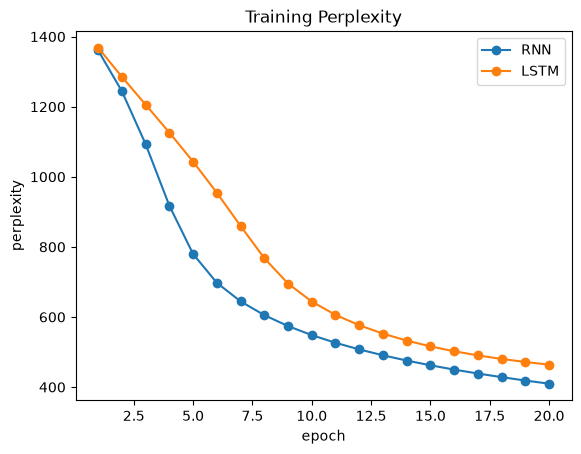

In [ ]:
import time

def make_sequence_batches(corpus, batch_size, time_size):
    xs = corpus[:-1]
    ts = corpus[1:]
    data_size = (len(xs) // batch_size) * batch_size
    batch_xs = xs[:data_size].reshape(batch_size, -1)
    batch_ts = ts[:data_size].reshape(batch_size, -1)
    return batch_xs, batch_ts


def evaluate_perplexity(model, corpus, batch_size, time_size):
    batch_xs, batch_ts = make_sequence_batches(corpus, batch_size, time_size)
    total_loss = 0.0
    loss_count = 0
    model.reset_state()

    # 평가에서는 backward와 가중치 갱신을 하지 않는다.
    for start in range(0, batch_xs.shape[1] - time_size + 1, time_size):
        batch_x = batch_xs[:, start:start + time_size]
        batch_t = batch_ts[:, start:start + time_size]
        total_loss += model.forward(batch_x, batch_t)
        loss_count += 1

    model.reset_state()
    return float(np.exp(total_loss / loss_count))


def train_language_model(model, model_name, train_data,
                        batch_size, time_size, learning_rate, max_epoch):
    batch_xs, batch_ts = make_sequence_batches(train_data, batch_size, time_size)
    train_history = []
    start_time = time.perf_counter()

    print(f'\n[{model_name}]')
    for epoch in range(1, max_epoch + 1):
        total_loss = 0.0
        loss_count = 0
        model.reset_state()

        for start in range(0, batch_xs.shape[1] - time_size + 1, time_size):
            batch_x = batch_xs[:, start:start + time_size]
            batch_t = batch_ts[:, start:start + time_size]

            loss = model.forward(batch_x, batch_t)
            model.backward()
            clip_grads(model.grads, max_norm=5.0)

            for param, grad in zip(model.params, model.grads):
                param -= learning_rate * grad

            total_loss += loss
            loss_count += 1

        train_ppl = float(np.exp(total_loss / loss_count))
        train_history.append(train_ppl)
        print(f'epoch {epoch:2d} | train PPL {train_ppl:.2f}')

    elapsed_time = time.perf_counter() - start_time
    return train_history, elapsed_time


compare_batch_size = 10
compare_time_size = 10
compare_wordvec_size = 16
compare_hidden_size = 16
compare_learning_rate = 0.1
compare_max_epoch = 20
vocab_size = len(word_to_id)

np.random.seed(42)
rnn_model = SimpleRNNlm(vocab_size, compare_wordvec_size, compare_hidden_size)
np.random.seed(42)
lstm_model = LSTMlm(vocab_size, compare_wordvec_size, compare_hidden_size)

rnn_train_ppl, rnn_time = train_language_model(
    rnn_model, 'Simple RNN', train_corpus,
    compare_batch_size, compare_time_size, compare_learning_rate, compare_max_epoch
)
lstm_train_ppl, lstm_time = train_language_model(
    lstm_model, 'LSTM', train_corpus,
    compare_batch_size, compare_time_size, compare_learning_rate, compare_max_epoch
)

# 학습에 사용하지 않은 test 데이터로 최종 평가한다.
rnn_test_ppl = evaluate_perplexity(rnn_model, test_corpus, compare_batch_size, compare_time_size)
lstm_test_ppl = evaluate_perplexity(lstm_model, test_corpus, compare_batch_size, compare_time_size)
rnn_params = sum(param.size for param in rnn_model.params)
lstm_params = sum(param.size for param in lstm_model.params)

print('\n[최종 비교]')
print(f'RNN  | params {rnn_params:,} | time {rnn_time:.2f}s | test PPL {rnn_test_ppl:.2f}')
print(f'LSTM | params {lstm_params:,} | time {lstm_time:.2f}s | test PPL {lstm_test_ppl:.2f}')

epochs = range(1, compare_max_epoch + 1)
plt.plot(epochs, rnn_train_ppl, marker='o', label='RNN')
plt.plot(epochs, lstm_train_ppl, marker='o', label='LSTM')
plt.title('Training Perplexity')
plt.xlabel('epoch')
plt.ylabel('perplexity')
plt.legend()
plt.show()

---
## LAB3: Dropout을 적용한 2층 LSTM 언어 모델

`TimeEmbedding → TimeDropout → TimeLSTM → TimeDropout → TimeLSTM → TimeDropout → TimeAffine → TimeSoftmaxWithLoss`

In [40]:
# 시간축 데이터를 위한 Dropout 계층
class TimeDropout:
    def __init__(self, dropout_ratio=0.5):
        self.params, self.grads = [], []
        self.dropout_ratio = dropout_ratio
        self.mask = None
        self.train_flg = True

    def forward(self, xs):
        if self.train_flg:
            keep_ratio = 1.0 - self.dropout_ratio
            self.mask = (np.random.rand(*xs.shape) < keep_ratio).astype('f')
            self.mask /= keep_ratio
            return xs * self.mask

        self.mask = None
        return xs

    def backward(self, dout):
        if self.mask is None:
            return dout
        return dout * self.mask


In [41]:
class MultiLayerLSTMlm:
    def __init__(self, vocab_size, wordvec_size=100, hidden_size=100, dropout_ratio=0.5):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # Embedding 가중치
        embed_W = (rn(V, D) / 100).astype('f')

        # 첫 번째 LSTM: D차원 임베딩을 H차원 은닉 상태로 변환
        lstm_Wx1 = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh1 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b1 = np.zeros(4 * H).astype('f')

        # 두 번째 LSTM: 첫 번째 LSTM의 H차원 출력을 입력받음
        lstm_Wx2 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_Wh2 = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b2 = np.zeros(4 * H).astype('f')

        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.layers = [
            TimeEmbedding(embed_W),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx1, lstm_Wh1, lstm_b1, stateful=True),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx2, lstm_Wh2, lstm_b2, stateful=True),
            TimeDropout(dropout_ratio),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layers = [self.layers[2], self.layers[4]]
        self.dropout_layers = [self.layers[1], self.layers[3], self.layers[5]]

        # 학습 대상 매개변수와 기울기를 모두 모은다.
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs, train_flg=False):
        # 학습할 때만 Dropout을 적용한다.
        for layer in self.dropout_layers:
            layer.train_flg = train_flg

        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts, train_flg=True):
        scores = self.predict(xs, train_flg)
        return self.loss_layer.forward(scores, ts)

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        for lstm_layer in self.lstm_layers:
            lstm_layer.reset_state()


epoch  1 | loss 7.2540 | perplexity 1413.76
epoch  2 | loss 7.0008 | perplexity 1097.55
epoch  3 | loss 6.6606 | perplexity 781.02
epoch  4 | loss 6.5026 | perplexity 666.89
epoch  5 | loss 6.4225 | perplexity 615.55


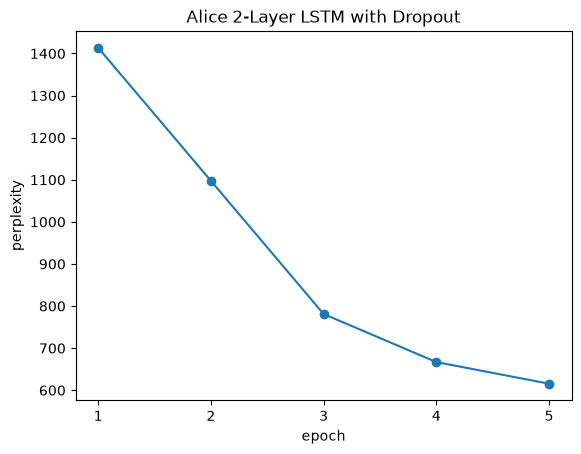

In [43]:
# LAB1의 Alice 데이터로 2층 LSTM 학습
multi_xs = alice_corpus[:-1]
multi_ts = alice_corpus[1:]

np.random.seed(42)
multi_batch_size = 5
multi_time_size = 5
multi_wordvec_size = 16
multi_hidden_size = 32
multi_dropout_ratio = 0.3
multi_learning_rate = 0.1
multi_max_epoch = 5

multi_model = MultiLayerLSTMlm(
    vocab_size=len(alice_word_to_id),
    wordvec_size=multi_wordvec_size,
    hidden_size=multi_hidden_size,
    dropout_ratio=multi_dropout_ratio
)

# 말뭉치를 batch_size개의 연속된 줄로 나눈다.
multi_data_size = (len(multi_xs) // multi_batch_size) * multi_batch_size
multi_batch_xs = multi_xs[:multi_data_size].reshape(multi_batch_size, -1)
multi_batch_ts = multi_ts[:multi_data_size].reshape(multi_batch_size, -1)
multi_ppl_history = []

for epoch in range(1, multi_max_epoch + 1):
    total_loss = 0.0
    loss_count = 0
    multi_model.reset_state()

    for start in range(0, multi_batch_xs.shape[1] - multi_time_size, multi_time_size):
        batch_x = multi_batch_xs[:, start:start + multi_time_size]
        batch_t = multi_batch_ts[:, start:start + multi_time_size]

        loss = multi_model.forward(batch_x, batch_t, train_flg=True)
        multi_model.backward()
        clip_grads(multi_model.grads, max_norm=5.0)

        for param, grad in zip(multi_model.params, multi_model.grads):
            param -= multi_learning_rate * grad

        total_loss += loss
        loss_count += 1

    mean_loss = total_loss / loss_count
    perplexity = float(np.exp(mean_loss))
    multi_ppl_history.append(perplexity)
    print(f'epoch {epoch:2d} | loss {mean_loss:.4f} | perplexity {perplexity:.2f}')


plt.plot(range(1, multi_max_epoch + 1), multi_ppl_history, marker='o')
plt.xlabel('epoch')
plt.ylabel('perplexity')
plt.title('Alice 2-Layer LSTM with Dropout')
plt.xticks(range(1, multi_max_epoch + 1))
plt.show()